In [ ]:
# import Pkg; Pkg.add("PhysicalConstants")
# using Pkg
# Pkg.instantiate()
# Pkg.precompile()
# ENV["PYTHON"] = "/mn/stornext/u3/harshm/env/bin/python3.12"
# using Pkg
# Pkg.build("PyCall")
using Pkg
Pkg.status("Muspel")

In [1]:
using Muspel
using StaticArrays
using AtomicData
using HDF5
using ProgressMeter
using Base.Threads
using Interpolations
using Mmap
using FortranFiles
using DelimitedFiles
using Unitful
using Base.Threads
using Plots
using Interpolations

In [2]:
h_atom = Muspel.read_atom("/mn/stornext/u3/harshm/Documents/WorkRepo/multi3d/input/atoms/atom.h6_tiago2.yaml")

[ Info: Could not parse Zeeman components for transition H BF N=2 → H BF N=1
[ Info: Could not parse Zeeman components for transition H BF N=3 → H BF N=1
[ Info: Could not parse Zeeman components for transition H BF N=4 → H BF N=1
[ Info: Could not parse Zeeman components for transition H BF N=5 → H BF N=1
[ Info: Could not parse Zeeman components for transition H BF N=3 → H BF N=2
[ Info: Could not parse Zeeman components for transition H BF N=4 → H BF N=2
[ Info: Could not parse Zeeman components for transition H BF N=5 → H BF N=2
[ Info: Could not parse Zeeman components for transition H BF N=4 → H BF N=3
[ Info: Could not parse Zeeman components for transition H BF N=5 → H BF N=3
[ Info: Could not parse Zeeman components for transition H BF N=5 → H BF N=4


┌ 6×10×6 AtomicModel{Float64, Int64} ┐
├────────────────────────────────────┴─────────────────────────────────── dims ┐
  Element: H (I, II)
  ⩸ 6 levels: 0.0, …, 2.18 aJ
  ↥ 10 lines: 94.98, …, 4052.0 nm
  ⩘ 6 continua: 91.11, …, 2239.0 nm
└──────────────────────────────────────────────────────────────────────────────┘

In [3]:
h_atom.lines

10-element Vector{AtomicLine} (490 wavelengths)
 λ₀ (nm):
 121.57  102.575  97.2562  94.9768  …  434.184  1875.74  1282.24  4052.45

In [4]:
mesh_file = "/mn/stornext/d9/data/harshm/bifrost_data/en024048_hion/mesh.en024048_hion"

"/mn/stornext/d9/data/harshm/bifrost_data/en024048_hion/mesh.en024048_hion"

In [5]:
atmos_file = "/mn/stornext/d9/data/harshm/bifrost_data/en024048_hion/atm3d.en024048_hion"

"/mn/stornext/d9/data/harshm/bifrost_data/en024048_hion/atm3d.en024048_hion"

In [6]:
pops_file = "/mn/stornext/d9/data/harshm/bifrost_data/en024048_hion_h6_252_3d_output/out_pop"

"/mn/stornext/d9/data/harshm/bifrost_data/en024048_hion_h6_252_3d_output/out_pop"

In [7]:
atmos = read_atmos_multi3d(mesh_file, atmos_file)

┌ 467×252×252 Atmosphere3D{Float32} ┐
├───────────────────────────────────┴──────────────────────────────────── dims ┐
  ↓ z 467 points: -1.021, …, 14.37 Mm
  → y 252 points: -23.91, …, -0.0 Mm
  ↗ x 252 points: 0.0, …, 23.91 Mm
├──────────────────────────────────────────────────────────── loaded in memory ┤
  data size: 905.04 MB
└──────────────────────────────────────────────────────────────────────────────┘

In [8]:
size(atmos.temperature)

(467, 252, 252)

In [9]:
pops = Muspel.saha_boltzmann.(
    Ref(h_atom),
    atmos.temperature,
    atmos.electron_density,
    atmos.hydrogen1_density .+ atmos.proton_density
)

467×252×252 Array{MVector{6, Float32}, 3}:
[:, :, 1] =
 [0.018227, 0.0606523, 0.131895, 0.2317, 0.360038, 1.21448f14]             …  [0.0184967, 0.0615072, 0.133737, 0.234925, 0.365042, 1.21943f14]
 [0.0182654, 0.0607151, 0.132005, 0.231877, 0.360302, 1.20961f14]             [0.0187253, 0.0621996, 0.135215, 0.237505, 0.369038, 1.22065f14]
 [0.0192106, 0.0638075, 0.138709, 0.243641, 0.378571, 1.23599f14]             [0.0195327, 0.0648362, 0.140929, 0.247529, 0.384606, 1.24261f14]
 [0.0206648, 0.0685776, 0.149054, 0.261797, 0.406772, 1.27667f14]             [0.0210552, 0.0698361, 0.151775, 0.266566, 0.414176, 1.28548f14]
 [0.0222017, 0.073617, 0.159983, 0.280977, 0.436563, 1.31819f14]              [0.0224882, 0.0745393, 0.161976, 0.284471, 0.441987, 1.32439f14]
 [0.0235241, 0.0779056, 0.169264, 0.297254, 0.461836, 1.34912f14]          …  [0.0237049, 0.0784894, 0.170527, 0.299467, 0.465272, 1.3531f14]
 [0.0249303, 0.0824222, 0.179021, 0.314353, 0.488378, 1.37797f14]             [0.0250517

In [10]:
pops_s = SVector{6,Float32}.(pops)

467×252×252 Array{SVector{6, Float32}, 3}:
[:, :, 1] =
 [0.018227, 0.0606523, 0.131895, 0.2317, 0.360038, 1.21448f14]             …  [0.0184967, 0.0615072, 0.133737, 0.234925, 0.365042, 1.21943f14]
 [0.0182654, 0.0607151, 0.132005, 0.231877, 0.360302, 1.20961f14]             [0.0187253, 0.0621996, 0.135215, 0.237505, 0.369038, 1.22065f14]
 [0.0192106, 0.0638075, 0.138709, 0.243641, 0.378571, 1.23599f14]             [0.0195327, 0.0648362, 0.140929, 0.247529, 0.384606, 1.24261f14]
 [0.0206648, 0.0685776, 0.149054, 0.261797, 0.406772, 1.27667f14]             [0.0210552, 0.0698361, 0.151775, 0.266566, 0.414176, 1.28548f14]
 [0.0222017, 0.073617, 0.159983, 0.280977, 0.436563, 1.31819f14]              [0.0224882, 0.0745393, 0.161976, 0.284471, 0.441987, 1.32439f14]
 [0.0235241, 0.0779056, 0.169264, 0.297254, 0.461836, 1.34912f14]          …  [0.0237049, 0.0784894, 0.170527, 0.299467, 0.465272, 1.3531f14]
 [0.0249303, 0.0824222, 0.179021, 0.314353, 0.488378, 1.37797f14]             [0.0250517

In [11]:
reinterpreted_pops_S = reshape(reinterpret(Float32, pops_s), 6, size(pops_s)...)

6×467×252×252 reshape(reinterpret(Float32, ::Array{SVector{6, Float32}, 3}), 6, 467, 252, 252) with eltype Float32:
[:, :, 1, 1] =
 0.018227    0.0182654   0.0192106   …  9.56025f23  9.9854f23   1.04453f24
 0.0606523   0.0607151   0.0638075      1.40125f21  1.54783f21  1.71384f21
 0.131895    0.132005    0.138709       7.28448f20  8.13031f20  9.09763f20
 0.2317      0.231877    0.243641       7.75501f20  8.68693f20  9.75637f20
 0.360038    0.360302    0.378571       9.55708f20  1.07235f21  1.20643f21
 1.21448f14  1.20961f14  1.23599f14  …  3.30269f23  3.5226f23   3.76269f23

[:, :, 2, 1] =
 0.0180312   0.0178642   0.0189346   …  9.5841f23   1.00258f24  1.0484f24
 0.0600344   0.0594154   0.0629242      1.39759f21  1.54574f21  1.70981f21
 0.130565    0.129193    0.136802       7.25858f20  8.11129f20  9.06609f20
 0.229371    0.226946    0.240299       7.72487f20  8.66358f20  9.71873f20
 0.356426    0.352646    0.373386       9.51848f20  1.0693f21   1.20155f21
 1.21116f14  1.19949f14  1.23

In [12]:
pops4d = permutedims(
    reinterpreted_pops_S,
    (3,4,2,1)
)

252×252×467×6 Array{Float32, 4}:
[:, :, 1, 1] =
 0.018227   0.0184418  0.0187021  …  0.0178441  0.0179497  0.018081
 0.0180312  0.0181868  0.0183817     0.0177168  0.0178181  0.0179032
 0.0178221  0.017932   0.0180951     0.0175581  0.0176399  0.0177169
 0.0175767  0.0176985  0.0177867     0.0173241  0.0174169  0.0174861
 0.0172964  0.0174203  0.0175234     0.0170136  0.0171286  0.0172148
 0.0169752  0.0170942  0.0172386  …  0.0166157  0.0167491  0.0168733
 0.0165889  0.0167193  0.0168527     0.01615    0.016332   0.0164576
 0.0161356  0.0162914  0.016443      0.0155314  0.0157937  0.0159729
 0.0155807  0.0157849  0.0159948     0.0148746  0.0151384  0.0153784
 0.0149771  0.0152187  0.0154855     0.0142786  0.014537   0.0146829
 0.0144095  0.0145543  0.014862   …  0.0138342  0.0139711  0.0141122
 0.0138342  0.0140053  0.0142697     0.0136955  0.0136966  0.0137581
 0.0136564  0.0136676  0.0137768     0.0135979  0.0136572  0.013676
 ⋮                                ⋱             ⋮        

In [13]:
function cmass_from_rho(ρ::AbstractVector{T}, z::AbstractVector{T}) where {T<:Real}
    n = length(ρ)
    cm = similar(ρ)
    cm[1] = zero(T)
    @inbounds for i in 2:n
        dz = -(z[i] - z[i-1])                # z increases upward
        cm[i] = cm[i-1] + 0.5*(ρ[i] + ρ[i-1]) * dz
    end
    return cm
end


function interpolate_column(
    ρ, z, Y, cmass_new;
    logx::Bool = false,
    logy::Bool = false
)
    cm = cmass_from_rho(ρ, z)

    # independent variable
    x    = logx ? log10.(cm)        : cm
    xnew = logx ? log10.(cmass_new) : cmass_new

    m     = length(cmass_new)
    nvars = size(Y, 2)

    out = Matrix{eltype(Y)}(undef, m, nvars)

    @inbounds for v in 1:nvars
        ycol = view(Y, :, v)
        y    = logy ? log10.(ycol) : ycol

        itp = LinearInterpolation(
            x, y,
            extrapolation_bc = Line()
        )

        vals = itp.(xnew)

        out[:, v] .= logy ? 10 .^ vals : vals
    end

    return out
end


"""
ρ_super   :: (nx, ny, nz)
pops4d    :: (nx, ny, nz, nvars)
cmass_new :: (m)

returns   :: (nx, ny, m, nvars)
"""
function interpolate_everything(
    ρ_super, z, pops4d, cmass_new;
    logx::Bool = false,
    logy::Bool = false
)

    nx, ny, nz = size(ρ_super)
    @assert size(pops4d,1) == nx
    @assert size(pops4d,2) == ny
    @assert size(pops4d,3) == nz

    nvars = size(pops4d, 4)
    m = length(cmass_new)

    out = Array{eltype(pops4d)}(undef, nx, ny, m, nvars)

    @threads for ix in 1:nx
        for iy in 1:ny
            ρ = view(ρ_super, ix, iy, :)

            # Force shape (nz, nvars) — prevents Julia collapsing dims
            Y = reshape(view(pops4d, ix, iy, :, :), nz, nvars)

            col = interpolate_column(ρ, z, Y, cmass_new; logx=logx, logy=logy)   # (m, nvars)

            @inbounds out[ix, iy, :, :] .= col
        end
    end

    return out
end

function compute_ztop(rho3d, z, mtop)
    nx, ny, nz = size(rho3d)
    ztop = Array{eltype(rho3d)}(undef, nx, ny)

    for ix in 1:nx, iy in 1:ny
        ρ = view(rho3d, ix, iy, :)
        cm = cmass_from_rho(ρ, z)
        itp = LinearInterpolation(cm, z, extrapolation_bc=Line())
        ztop[ix,iy] = itp(mtop)
    end
    return ztop
end

function invert_cmass(cmass, rho, ztop)
    N = length(cmass)
    z = similar(cmass)
    z[1] = ztop
    @inbounds for i = 2:N
        dm = cmass[i] - cmass[i-1]
        z[i] = z[i-1] - dm / rho[i-1]
    end
    return z
end

function compute_z_from_cmass_3d(rho_new, cmass_new, ztop)
    nx, ny, nz = size(rho_new)
    znew = Array{eltype(rho_new)}(undef, nx, ny, nz)

    for ix in 1:nx, iy in 1:ny
        znew[ix,iy,:] = invert_cmass(cmass_new, view(rho_new, ix, iy, :), ztop[ix,iy])
    end
    return znew
end

function remap_atmosphere_cmass(atmos::Atmosphere3D, new_cmass_scale)

    nx, ny, nz = atmos.nx, atmos.ny, atmos.nz

    # (nz,nx,ny) → (nx,ny,nz)
    temp = permutedims(atmos.temperature,       (2,3,1))
    vx   = permutedims(atmos.velocity_x,        (2,3,1))
    vy   = permutedims(atmos.velocity_y,        (2,3,1))
    vz   = permutedims(atmos.velocity_z,        (2,3,1))
    ne   = permutedims(atmos.electron_density,  (2,3,1))
    nh   = permutedims(atmos.hydrogen1_density, (2,3,1))
    np   = permutedims(atmos.proton_density,    (2,3,1))
    rho  = permutedims(atmos.plasma_density,    (2,3,1))

    # ztop at fixed cmass = new_cmass_scale[1]
    ztop = compute_ztop(rho, atmos.z, new_cmass_scale[1])

    # add phantom dimension
    f4(A) = reshape(A, nx, ny, nz, 1)
    temp4, vx4, vy4, vz4 = f4(temp), f4(vx), f4(vy), f4(vz)
    ne4, nh4, np4, rho4 = f4(ne), f4(nh), f4(np), f4(rho)

    # interpolate
    temp_new = dropdims(interpolate_everything(rho, atmos.z, temp4, new_cmass_scale; logx=true, logy=false), dims=4)
    vx_new   = dropdims(interpolate_everything(rho, atmos.z, vx4,   new_cmass_scale; logx=true, logy=false), dims=4)
    vy_new   = dropdims(interpolate_everything(rho, atmos.z, vy4,   new_cmass_scale; logx=true, logy=false), dims=4)
    vz_new   = dropdims(interpolate_everything(rho, atmos.z, vz4,   new_cmass_scale; logx=true, logy=false), dims=4)
    ne_new   = dropdims(interpolate_everything(rho, atmos.z, ne4,   new_cmass_scale; logx=true, logy=true), dims=4)
    nh_new   = dropdims(interpolate_everything(rho, atmos.z, nh4,   new_cmass_scale; logx=true, logy=true), dims=4)
    np_new   = dropdims(interpolate_everything(rho, atmos.z, np4,   new_cmass_scale; logx=true, logy=true), dims=4)
    rho_new  = dropdims(interpolate_everything(rho, atmos.z, rho4,  new_cmass_scale; logx=true, logy=true), dims=4)

    # rebuild geometric height
    z_new = compute_z_from_cmass_3d(rho_new, new_cmass_scale, ztop)

    # back to Atmosphere3D layout (nz,nx,ny)
    g(A) = permutedims(A, (3,1,2))

    return Atmosphere3D(
        nx,
        ny,
        length(z_new),
        atmos.x,
        atmos.y,
        g(z_new),
        g(temp_new),
        g(vx_new),
        g(vy_new),
        g(vz_new),
        g(ne_new),
        g(nh_new),
        g(np_new),
        g(rho_new)
    )
end


remap_atmosphere_cmass (generic function with 1 method)

In [14]:
new_cmass_scale = Float32.(10 .^ range(-6, 2, length=400))

400-element Vector{Float32}:
   1.0f-6
   1.0472494f-6
   1.0967314f-6
   1.1485513f-6
   1.2028196f-6
   1.2596521f-6
   1.31917f-6
   1.3814999f-6
   1.4467751f-6
   1.5151343f-6
   1.5867234f-6
   1.6616953f-6
   1.7402094f-6
   ⋮
  60.17951
  63.022953
  66.00075
  69.11925
  72.38509
  75.805244
  79.38699
  83.137985
  87.06621
  91.18003
  95.488235
 100.0

In [15]:
pops_new = interpolate_everything(PermutedDimsArray(atmos.plasma_density, (2, 3, 1)), atmos.z, pops4d, new_cmass_scale; logx=true, logy=true)

252×252×400×6 Array{Float32, 4}:
[:, :, 1, 1] =
 24.3681   26.0488   27.2535   28.0665   …  19.3325   21.2609   23.0224
 21.3769   23.4241   25.5842   27.3775      16.7415   18.0117   19.5847
 18.184    19.9861   22.1084   24.3267      14.6061   15.6582   16.8306
 15.5917   16.8653   18.4476   20.4255      12.3667   13.2827   14.4163
 13.0745   14.2183   15.3606   16.7697      10.5246   11.1562   12.0408
 10.9263   11.3715   12.3119   13.5538   …   9.07419   9.58909  10.2187
  9.49411   9.23712   9.60781  10.4943       8.4852    8.66347   9.19239
  9.0027    8.45406   8.36758   8.49656      9.05851   8.97976   8.98463
 10.1204    8.77338   8.12113   8.03257     11.1565   10.6042   10.5717
 12.9451   11.2576    9.74762   8.91821     15.7626   14.6376   13.9052
 19.4885   16.1366   13.4356   11.7665   …  25.8412   23.2748   21.5285
 33.1049   27.4855   23.0269   19.0392      40.5375   39.0619   37.0965
 53.3641   47.6786   40.528    34.946       60.3177   58.7804   56.5462
  ⋮           

In [16]:
maximum(pops_new)

3.7443767f23

In [17]:
f = h5open("sunnynet_output_3D_sim_s5_3x3.hdf5", "r")

🗂️ HDF5.File: (read-only) sunnynet_output_3D_sim_s5_3x3.hdf5
└─ 🔢 populations
   └─ 🏷️ cmass_scale

In [18]:
raw = HDF5.readmmap(f["populations"])   # now it's a real Array-backed view

6×400×252×252 Array{Float32, 4}:
[:, :, 1, 1] =
  2.76691f8   2.75858f8   2.71036f8  …  3.68796   3.60753   3.71564
 14.5981     15.3846     15.9106        1.33963   1.35446   1.33515
  2.12797     2.21478     2.23492       0.839222  0.848039  0.844234
  1.33231     1.37033     1.3609        0.615334  0.620763  0.616931
  1.0854      1.11173     1.06798       0.391983  0.398197  0.394804
  1.00001     0.99993     1.0        …  0.999822  0.999829  0.999883

[:, :, 2, 1] =
  3.23257f8   3.23499f8   3.19346f8  …  3.75731   3.62136   3.71005
 15.4163     16.2768     16.8246        1.35259   1.36487   1.34801
  2.18019     2.2765      2.3064        0.836329  0.848065  0.845187
  1.35481     1.39859     1.39849       0.609296  0.619083  0.616248
  1.11957     1.15171     1.11275       0.385977  0.396042  0.393363
  0.999961    0.999922    0.999998   …  0.999833  0.999904  0.999923

[:, :, 3, 1] =
  2.93075f8   2.91644f8   2.86695f8  …  3.85316   3.65822   3.71887
 16.4799     17.1518     17.

In [19]:
dep_coeff = PermutedDimsArray(raw, (3, 4, 2, 1))

252×252×400×6 PermutedDimsArray(::Array{Float32, 4}, (3, 4, 2, 1)) with eltype Float32:
[:, :, 1, 1] =
 2.76691f8  2.42029f8  1.79677f8  …  4.01821f8  3.29921f8  3.55453f8
 3.23257f8  2.26957f8  1.97614f8     3.9575f8   4.26387f8  4.08076f8
 2.93075f8  2.20953f8  1.97338f8     3.61498f8  4.64945f8  4.0655f8
 3.0298f8   2.80984f8  2.73626f8     3.52536f8  3.59513f8  2.73231f8
 2.85498f8  3.61371f8  3.59225f8     2.22388f8  3.14155f8  3.83213f8
 4.51722f8  2.91455f8  1.7582f8   …  2.65487f8  2.27881f8  2.59708f8
 2.74139f8  4.72783f8  3.94729f8     2.31266f8  3.09486f8  2.67335f8
 2.26553f8  2.18774f8  4.41785f8     2.58765f8  2.65389f8  2.60660f8
 2.51164f8  2.78421f8  3.83366f8     3.09518f8  2.62144f8  3.32766f8
 3.10561f8  3.12422f8  4.3741f8      3.59297f8  2.54463f8  3.21224f8
 2.39647f8  3.0303f8   3.24185f8  …  2.54198f8  2.31438f8  2.0116f8
 1.41472f8  1.74689f8  2.19396f8     2.10561f8  2.02909f8  1.68272f8
 1.4368f8   1.34434f8  1.48631f8     2.33551f8  2.14635f8  1.72984f8
 ⋮

In [20]:
nlte_populations = dep_coeff .* pops_new

252×252×400×6 Array{Float32, 4}:
[:, :, 1, 1] =
 6.74241f9   6.30456f9   4.89682f9   …  7.76821f9   7.01442f9   8.1834f9
 6.91024f9   5.31626f9   5.0558f9       6.62544f9   7.67994f9   7.99204f9
 5.32927f9   4.41598f9   4.36282f9      5.28007f9   7.28022f9   6.84249f9
 4.72397f9   4.73889f9   5.04776f9      4.35969f9   4.77529f9   3.93899f9
 3.73276f9   5.13806f9   5.51792f9      2.34055f9   3.50479f9   4.61421f9
 4.93567f9   3.31428f9   2.16467f9   …  2.40908f9   2.18518f9   2.65387f9
 2.6027f9    4.36715f9   3.79248f9      1.96233f9   2.68122f9   2.45745f9
 2.03959f9   1.84953f9   3.69667f9      2.34402f9   2.38313f9   2.34193f9
 2.54188f9   2.44269f9   3.11337f9      3.45314f9   2.77984f9   3.5179f9
 4.02023f9   3.51714f9   4.26371f9      5.66345f9   3.72473f9   4.46666f9
 4.67035f9   4.88988f9   4.35562f9   …  6.56877f9   5.38666f9   4.33066f9
 4.68342f9   4.80141f9   5.05202f9      8.53562f9   7.92601f9   6.24231f9
 7.66736f9   6.40961f9   6.02374f9      1.40873f10  1.26163f10  9.

In [21]:
reshaped_nlte_pops = permutedims(nlte_populations, (3, 4, 1, 2))

400×6×252×252 Array{Float32, 4}:
[:, :, 1, 1] =
 6.74241f9    77.5264      14.8346      13.6737      15.9508      9.09025f13
 1.02385f10  119.789       22.4778      20.4244      23.6992      1.08307f14
 1.30605f10  164.134       30.1647      27.0106      30.3354      1.25755f14
 1.13368f10  178.879       32.8523      29.4379      32.419       1.39495f14
 6.85558f9   156.732       30.0941      27.2677      29.8528      1.52537f14
 1.98016f9    90.6609      19.2764      17.9319      19.6594      1.62419f14
 8.06455f8    59.4446      13.2918      12.5688      13.5848      1.71093f14
 7.92333f8    64.8818      14.3202      13.3986      14.1949      1.85912f14
 1.0509f9     84.0733      17.9136      16.4007      17.0379      2.00272f14
 1.88003f9   128.361       25.5334      22.7228      22.8935      2.12057f14
 2.42162f9   159.401       30.0817      26.193       25.5841      2.20295f14
 2.13685f9   153.237       28.2437      24.2801      23.1863      2.1846f14
 1.07611f9   103.839       19

In [22]:
remapped_atmos = remap_atmosphere_cmass(atmos, new_cmass_scale)

┌ 25401600×252×252 Atmosphere3D{Float32} ┐
├────────────────────────────────────────┴─────────────────────────────── dims ┐
  ↓ z 25401600 points: -1.247, …, 12.27 Mm
  → y 252 points: -23.91, …, -0.0 Mm
  ↗ x 252 points: 0.0, …, 23.91 Mm
├──────────────────────────────────────────────────────────── loaded in memory ┤
  data size: 872.1 MB
└──────────────────────────────────────────────────────────────────────────────┘

In [23]:
pops_out_nlte, pops_out_lte = read_pops_multi3d(pops_file, atmos.nx, atmos.ny, atmos.nz, h_atom.nlevels)

(Float32[7.5210765f6 7.4572085f6 … 7.695472f6 7.605963f6; 7.570647f6 7.4663025f6 … 7.799902f6 7.692471f6; … ; 9.691666f23 9.732168f23 … 9.652867f23 9.6541194f23; 1.0126325f24 1.0165368f24 … 1.00857566f24 1.0095034f24;;; 7.598006f6 7.5168125f6 … 7.803012f6 7.6951625f6; 7.673952f6 7.552415f6 … 7.922543f6 7.7944595f6; … ; 9.660211f23 9.6789655f23 … 9.6111485f23 9.634463f23; 1.0083384f24 1.0104023f24 … 1.0055515f24 1.00730154f24;;; 7.6908015f6 7.5919795f6 … 7.9192155f6 7.79944f6; 7.776651f6 7.652683f6 … 8.068179f6 7.91698f6; … ; 9.620922f23 9.635144f23 … 9.5964755f23 9.606102f23; 1.0054418f24 1.0064025f24 … 1.0047214f24 1.00410586f24;;; … ;;; 7.373196f6 7.334496f6 … 7.4478595f6 7.4082435f6; 7.5264385f6 7.4798465f6 … 7.590288f6 7.55994f6; … ; 9.767477f23 9.8534184f23 … 9.679968f23 9.697007f23; 1.0222055f24 1.0304951f24 … 1.0109846f24 1.01370025f24;;; 7.4146105f6 7.3714f6 … 7.5201895f6 7.4625665f6; 7.5138215f6 7.47808f6 … 7.630417f6 7.5596265f6; … ; 9.773585f23 9.850946f23 … 9.6681526f23 9.6

In [24]:
size(pops_out_lte)

(467, 252, 252, 6)

In [25]:
pops_out_lte_new_cmass = PermutedDimsArray(
    interpolate_everything(
        PermutedDimsArray(atmos.plasma_density, (2, 3, 1)),
        atmos.z,
        PermutedDimsArray(pops_out_lte, (2, 3, 1, 4)),
        new_cmass_scale;
        logx=true,
        logy=true
        ),
    (3, 1, 2, 4)
)

400×252×252×6 PermutedDimsArray(::Array{Float32, 4}, (3, 1, 2, 4)) with eltype Float32:
[:, :, 1, 1] =
 24.3689      21.3776      18.1846      …  28.0397      26.8273
 37.1163      29.9035      20.8036         43.1466      41.1797
 48.1889      33.7706      17.2283         57.5543      54.2252
 42.9131      24.029       10.1707         63.7978      55.9474
 27.1518      10.466        3.44905        54.9216      43.9332
  8.16437      2.76885      1.18893     …  35.1551      20.8785
  3.4525       1.72729      1.0137         14.7759       7.52457
  3.51445      2.02189      1.27931         9.74728      6.1909
  4.85999      3.14723      1.99834        10.5365       7.58604
  9.2008       6.28937      3.69047        12.2773      11.241
 12.3398      11.0426       7.4435      …  12.4851      12.6285
 11.4835      12.0571      11.0628          8.53151     10.2214
  6.13648      9.2848      11.1271          1.91681      3.41
  ⋮                                     ⋱   ⋮           
  1.60466

In [26]:
pops_out_nlte_new_cmass = PermutedDimsArray(
    interpolate_everything(
        PermutedDimsArray(atmos.plasma_density, (2, 3, 1)),
        atmos.z,
        PermutedDimsArray(pops_out_nlte, (2, 3, 1, 4)),
        new_cmass_scale;
        logx=true,
        logy=true
        ),
    (3, 1, 2, 4)
)

400×252×252×6 PermutedDimsArray(::Array{Float32, 4}, (3, 1, 2, 4)) with eltype Float32:
[:, :, 1, 1] =
 3.68561f10  3.25785f10  2.81755f10  …  4.09283f10  4.10885f10  4.00064f10
 4.57903f10  3.75818f10  2.73943f10     5.27242f10  5.23682f10  5.04212f10
 5.11298f10  3.77774f10  2.08122f10     6.04607f10  5.97333f10  5.67148f10
 4.27511f10  2.54709f10  1.1244f10      6.14585f10  5.94333f10  5.32239f10
 2.58635f10  1.0294f10   3.34235f9      5.32851f10  4.82785f10  3.98954f10
 7.34753f9   2.40755f9   9.85984f8   …  3.8934f10   3.02303f10  1.85554f10
 2.80747f9   1.34032f9   7.48328f8      1.81764f10  1.23772f10  6.30267f9
 2.60035f9   1.41661f9   8.56866f8      9.56074f9   7.56095f9   4.7501f9
 3.37758f9   2.11389f9   1.29042f9      8.74289f9   7.59173f9   5.40803f9
 6.22565f9   4.14866f9   2.32891f9      8.83916f9   8.47195f9   7.69083f9
 8.12595f9   7.08128f9   4.5987f9    …  8.36304f9   8.54682f9   8.48282f9
 7.61191f9   7.65477f9   6.69845f9      4.74734f9   5.95942f9   6.96955f9
 4.0

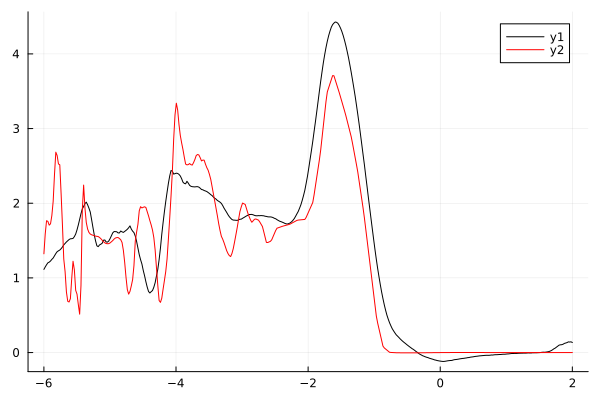

In [27]:
a = firstindex(new_cmass_scale)
b = lastindex(new_cmass_scale)
y = 21
x = 33
plot(log10.(new_cmass_scale)[a:b], log10.(PermutedDimsArray(dep_coeff, (3, 1, 2, 4))[a:b, x, y, 2]), color="black")
plot!(log10.(new_cmass_scale)[a:b], log10.(pops_out_nlte_new_cmass[a:b, x, y, 2] ./ pops_out_lte_new_cmass[a:b, x, y, 2]), color="red")

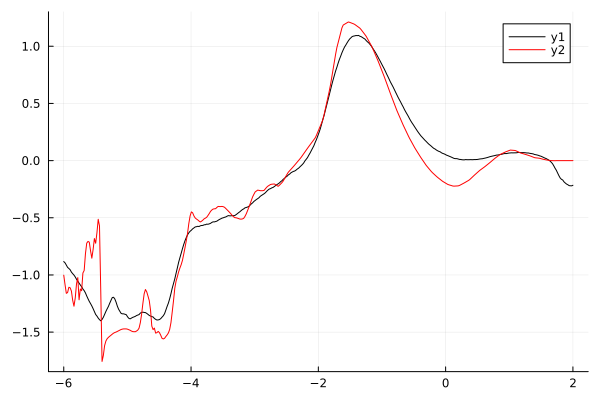

In [28]:
a = firstindex(new_cmass_scale)
b = lastindex(new_cmass_scale)
y = 21
x = 33
orig_dep_coeff_2 = pops_out_nlte_new_cmass[a:b, x, y, 2] ./ pops_out_lte_new_cmass[a:b, x, y, 2]
orig_dep_coeff_3 = pops_out_nlte_new_cmass[a:b, x, y, 3] ./ pops_out_lte_new_cmass[a:b, x, y, 3]
pred_dep_coeff_2 = PermutedDimsArray(dep_coeff, (3, 1, 2, 4))[a:b, x, y, 2]
pred_dep_coeff_3 = PermutedDimsArray(dep_coeff, (3, 1, 2, 4))[a:b, x, y, 3]
plot(log10.(new_cmass_scale)[a:b], log10.(pred_dep_coeff_3 ./ pred_dep_coeff_2), color="black")
plot!(log10.(new_cmass_scale)[a:b], log10.(orig_dep_coeff_3 ./ orig_dep_coeff_2), color="red")

In [29]:
h_atom.g

6-element SVector{6, Int64} with indices SOneTo(6):
  2
  8
 18
 32
 50
  1

In [30]:
permutted_reshaped_nlte_pops = PermutedDimsArray(reshaped_nlte_pops, (1, 3, 4, 2))

400×252×252×6 PermutedDimsArray(::Array{Float32, 4}, (1, 3, 4, 2)) with eltype Float32:
[:, :, 1, 1] =
 6.74241f9   6.91024f9   5.32927f9   …  8.36557f9   4.8333f9    7.22804f9
 1.02385f10  9.67343f9   6.06706f9      1.26852f10  7.29683f9   1.09717f10
 1.30605f10  1.07842f10  4.93912f9      1.64691f10  9.48036f9   1.41071f10
 1.13368f10  7.51147f9   2.87088f9      1.81641f10  1.02179f10  1.41229f10
 6.85558f9   3.13217f9   9.41803f8      1.64143f10  8.47708f9   1.05937f10
 1.98016f9   7.98288f8   3.14941f8   …  1.1917f10   5.20588f9   4.82557f9
 8.06455f8   4.79863f8   2.58746f8      5.3231f9    2.09772f9   1.67107f9
 7.92333f8   5.42879f8   3.15224f8      2.81454f9   1.3286f9    1.32281f9
 1.0509f9    8.1233f8    4.73199f8      2.63668f9   1.37903f9   1.55237f9
 1.88003f9   1.5389f9    8.28498f8      2.61778f9   1.53525f9   2.1749f9
 2.42162f9   2.61544f9   1.62393f9   …  2.3511f9    1.50225f9   2.34582f9
 2.13685f9   2.72115f9   2.30979f9      1.22934f9   9.74727f8   1.80416f9
 1.076

In [31]:
const h  = 6.62607015e-34      # Planck constant [J s]
const c  = 2.99792458e8       # speed of light [m s⁻¹]
const λ  = 6562.8e-10         # wavelength [m]
const ν  = c / λ              # frequency [Hz]

# lower and upper level indices
l = 2
u = 3

# populations [m⁻3]
n_l = permutted_reshaped_nlte_pops[:, :, :, l]
n_u = permutted_reshaped_nlte_pops[:, :, :, u]

n_l_orig = pops_out_nlte_new_cmass[:, :, :, l]
n_u_orig = pops_out_nlte_new_cmass[:, :, :, u]

# statistical weights
g_l = h_atom.g[l]
g_u = h_atom.g[u]

prefactor = 2h * ν^3 / c^2   # [W m⁻2 Hz⁻1 sr⁻1]

Sν = prefactor ./ ((g_u .* n_l) ./ (g_l .* n_u) .- 1)
Sν_orig = prefactor ./ ((g_u .* n_l_orig) ./ (g_l .* n_u_orig) .- 1)

400×252×252 Array{Float64, 3}:
[:, :, 1] =
 3.72657e-8  3.97876e-8  4.12466e-8  …  3.24679e-8  3.36243e-8  3.51185e-8
 4.73442e-8  4.9611e-8   5.13797e-8     4.32039e-8  4.5284e-8   4.61642e-8
 5.4339e-8   5.54309e-8  5.58646e-8     5.05459e-8  5.05928e-8  5.2273e-8
 6.01839e-8  5.94035e-8  6.2055e-8      5.63859e-8  5.85948e-8  6.03599e-8
 6.62672e-8  7.13045e-8  8.71163e-8     6.66782e-8  6.84654e-8  6.75861e-8
 8.06648e-8  1.02937e-7  1.27891e-7  …  7.6304e-8   7.40972e-8  7.29233e-8
 1.0387e-7   1.27608e-7  1.49401e-7     7.95565e-8  7.78941e-8  8.51189e-8
 1.18109e-7  1.45992e-7  1.71982e-7     8.4452e-8   8.55914e-8  9.67829e-8
 1.26498e-7  1.45274e-7  1.64598e-7     8.87263e-8  9.37359e-8  1.07176e-7
 1.03077e-7  1.16018e-7  1.3728e-7      9.50778e-8  9.85853e-8  9.96257e-8
 9.15965e-8  9.73388e-8  1.13569e-7  …  9.46556e-8  9.11822e-8  8.98952e-8
 9.14143e-8  9.85919e-8  1.13109e-7     1.00891e-7  9.42476e-8  9.10569e-8
 1.15344e-7  1.14339e-7  1.1863e-7      1.70692e-7  1.4428

In [32]:
Sν[:, 33, 21] == Sν_orig[:, 33, 21]

false

In [33]:
minimum(pops_out_nlte_new_cmass)

0.023327058f0

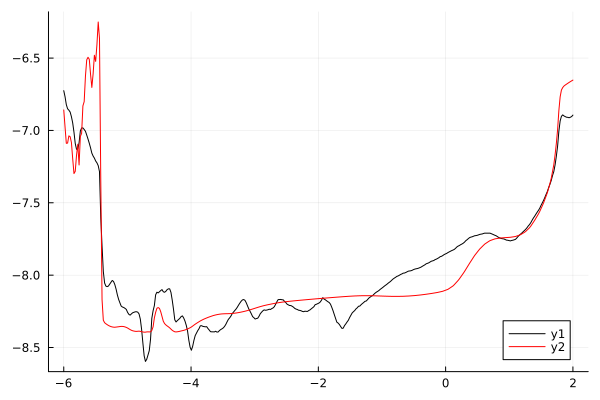

In [46]:
a = firstindex(new_cmass_scale)
b = lastindex(new_cmass_scale)
y = 21
x = 33
# xlims = (-5, 1)
plot(log10.(new_cmass_scale)[a:b], log10.(Sν[a:b, x, y]), color="black")
plot!(log10.(new_cmass_scale)[a:b], log10.(Sν_orig[a:b, x, y]), color="red")
# plot!(log10.(new_cmass_scale)[a:b], log10.(pops_out_nlte_new_cmass[a:b, x, y, 2]), color="navy", right_axis = true)
# plot!(log10.(new_cmass_scale)[a:b], log10.(permutted_reshaped_nlte_pops[a:b, x, y, 2]), color="green", right_axis = true)

In [36]:
h_atom.χ

6-element SVector{6, Float64} with indices SOneTo(6):
 0.0
 1.6339941854018686e-18
 1.936585907218822e-18
 2.0424878450955273e-18
 2.091506177644877e-18
 2.1802152677122893e-18

In [37]:
remapped_atmos.z[:, 33, 21]/1e3

400-element Vector{Float64}:
 10648.728
 10503.482
 10348.459
 10185.381
 10019.927
  9854.966
  9678.762
  9481.36
  9249.111
  8977.593
  8687.068
  8409.998
  8143.4915
     ⋮
  -277.57084375
  -288.384375
  -300.35890625
  -312.9093125
  -325.75334375
  -338.7950625
  -351.933875
  -365.15053125
  -378.44115625
  -391.80396875
  -405.245625
  -418.77690625

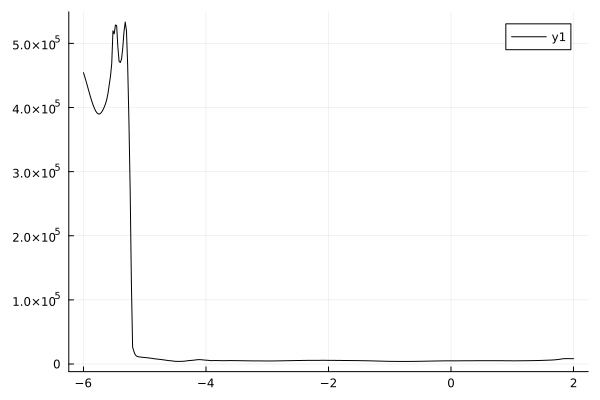

In [38]:
a = firstindex(new_cmass_scale)
b = lastindex(new_cmass_scale)
y = 50
x = 100
plot(log10.(new_cmass_scale)[a:b], remapped_atmos.temperature[a:b, x, y], color="black")

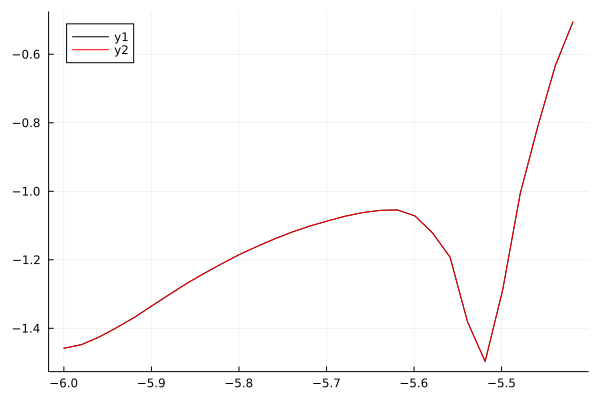

In [39]:
a = 1  #firstindex(new_cmass_scale)
b = 30  #lastindex(new_cmass_scale)
y = 50
x = 100
plot(log10.(new_cmass_scale)[a:b], log10.(pops_new)[x, y, a:b, 1], color="black")
plot!(log10.(new_cmass_scale)[a:b], log10.(pops_out_lte_new_cmass)[a:b, x, y, 1], color="red")

In [40]:
minimum(remapped_atmos.electron_density)

4.784791f13

In [41]:
my_line = h_atom.lines[5]
atms = remapped_atmos
nltepops = PermutedDimsArray(reshaped_nlte_pops, (1, 3, 4, 2))

a = LinRange(1f-4, 1f1, 20000)
v = LinRange(0f0, 5f2, 2500)
voigt_itp = create_voigt_itp(a, v)

intensity = Array{Float32, 3}(undef, my_line.nλ, atms.ny, atms.nx)
p = ProgressMeter.Progress(atms.nx)

n_u = nltepops[:, :, :, 3]
n_l = nltepops[:, :, :, 2]

# Continuum opacity structures
bckgr_atoms = [
    "Al.yaml",
    "C.yaml",
    "Ca.yaml",
    "Fe.yaml",
    "H_6.yaml",
    "He.yaml",
    "KI.yaml",
    "Mg.yaml",
    "N.yaml",
    "Na.yaml",
    "NiI.yaml",
    "O.yaml",
    "S.yaml",
    "Si.yaml",
]
atom_files = [joinpath(AtomicData.get_atom_dir(), a) for a in bckgr_atoms]
σ_itp = get_σ_itp(atms, my_line.λ0, atom_files)

a = LinRange(1f-4, 1f1, 20000)
v = LinRange(0f0, 5f2, 2500)
voigt_itp = create_voigt_itp(a, v)

intensity = Array{Float32, 3}(undef, my_line.nλ, atms.ny, atms.nx)
p = ProgressMeter.Progress(atms.nx)
Threads.@threads for i in 1:atms.nx
    buf = RTBuffer(atms.nz, my_line.nλ, Float32)  # allocate inside for local scope
    for j in 1:atms.ny
        calc_line_prep!(my_line, buf, atms[:, j, i], σ_itp)
        calc_line_1D!(my_line, buf, my_line.λ, atms[:, j, i], n_u[:, i, j], n_l[:, i, j], voigt_itp)
        intensity[:, j, i] = buf.intensity
    end
    ProgressMeter.next!(p)
end

Progress: 100%|█████████████████████████████████████████| Time: 0:01:43


In [42]:
intensity[51, :, :]

252×252 Matrix{Float32}:
 6.55233  6.09972  6.16134  7.03319  …  6.60394  6.65465  6.47815   6.68142
 7.09276  6.71131  6.54683  6.14934     6.72561  8.2524   6.43418   7.41198
 7.65007  6.63382  6.57438  6.58005     4.95431  7.11573  7.84199   7.64215
 7.6842   6.84784  6.75642  6.65804     4.51052  4.7618   8.32407   9.0083
 7.99719  6.9757   6.60796  6.32962     4.1256   4.43105  5.55158  11.2091
 7.97597  6.53777  6.20964  6.23171  …  5.13046  4.55721  4.82447   6.98791
 7.22658  7.25746  6.49839  6.33667     5.77335  5.18549  5.19136   5.77429
 7.16241  7.49847  7.94152  7.31724     6.19746  5.75044  5.46974   5.56017
 7.56196  8.1551   9.18047  7.98268     6.43072  6.43232  5.44032   5.01149
 5.98509  9.9323   9.28061  8.26818     6.63132  6.08474  5.29551   4.86481
 5.18083  7.14056  8.49411  8.1157   …  6.61963  6.06216  5.26019   4.70249
 4.41021  5.11868  6.60493  7.26555     6.21884  6.31697  5.48353   4.53522
 3.73379  4.10142  5.27789  5.63324     5.30131  6.3137   5.51941

In [43]:
my_line.λ

101-element Vector{Float64}:
 654.6954518893249
 655.014428765943
 655.2743561370064
 655.4861850371302
 655.6588472398591
 655.7996236346072
 655.9144467456523
 656.0081487056965
 656.0846642142307
 656.1471964513664
 656.198352575828
 656.2402542953145
 656.2746280372243
   ⋮
 656.7144454109537
 656.756413068956
 656.8076642356472
 656.8703343753482
 656.9470511551161
 657.0410483980369
 657.1563066776678
 657.2977269145831
 657.4713449222007
 657.6845968647744
 657.9466481684589
 658.2688017483085

In [44]:
f = h5open("intensity_ml_3x3.h5", "w")
f["intensity"] = intensity
f["wave_HA"] = my_line.λ
close(f)

In [ ]:
new_cmass_scale

In [ ]:
intensity.size